# Harmony Filtering Service Demo

This notebook shows how to run the core filtering pipeline, using the  
`settings.json` and `config.json` in `config/`.

Before running, make sure:

```bash
pip install -r docs/requirements.txt

In [1]:
# 1️⃣ Set up imports
import json
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import resource

from harmony_filtering_service.adapter_utils import load_and_prepare_settings
from harmony_filtering_service.core import process_products

# so that inline plots appear
%matplotlib inline

In [2]:
# 2️⃣ Load and prepare the settings.json
settings_path = Path("../config/settings.json")
settings = load_and_prepare_settings(settings_path)
print("Data dir:", settings["data_dir"])
print("Output dir:", settings["output_dir"])

Data dir: /Users/jryan/podaac/code/harmony-filtering-service/docs/data/in_data
Output dir: /Users/jryan/podaac/code/harmony-filtering-service/docs/data/out_data


In [3]:
# 3️⃣ Load the filter config (config/config.json)
cfg_path = Path("../config/config.json")
config = json.loads(cfg_path.read_text(encoding="utf-8"))
config

{'O3TOT': {'filters': {'pixel_filter': [{'target_var': 'product/column_amount_o3',
     'criteria_var': 'geolocation/solar_zenith_angle',
     'operator': 'greater-than',
     'threshold': '80',
     'target_value': 'nan',
     'level': 'all'},
    {'target_var': 'product/column_amount_o3',
     'criteria_var': 'geolocation/viewing_zenith_angle',
     'operator': 'greater-than',
     'threshold': '80',
     'target_value': 'nan',
     'level': 'all'},
    {'target_var': 'product/column_amount_o3',
     'criteria_var': 'product/quality_flag',
     'operator': 'in',
     'threshold': [0, 1, 2, 5],
     'target_value': 'nan',
     'level': '2'},
    {'target_var': 'product/column_amount_o3',
     'criteria_var': 'product/column_amount_o3',
     'operator': 'less-than',
     'threshold': '100',
     'target_value': '100',
     'level': 'all'},
    {'target_var': 'product/column_amount_o3',
     'criteria_var': 'product/column_amount_o3',
     'operator': 'greater-than',
     'threshold': '

In [4]:
# 4️⃣ Run the filtering pipeline
#process_products(settings, {"MUR": config["MUR"]}, "20260302090000-JPL-L4_GHRSST-SSTfnd-MUR25-GLOB-v02.0-fv04.2.nc", "analysed_sst")
process_products(settings, {"O3TOT": config["O3TOT"]}, "TEMPO_O3TOT_L3_V04_20250912T234443Z_S015.nc", "product/column_amount_o3")
peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
print(f"Peak memory: {peak / (1024**2):.2f} MB", flush=True)  # B to MB on MacOS
print("✅ Done filtering.")

=== Entered process_products ===
[INFO] Parsed metadata: {'instrument': 'TEMPO', 'product': 'O3TOT', 'level': '3', 'version': 'V04', 'timestamp': '20250912T234443Z', 'sequence': 'S015'}
[INFO] Applying 12 filter rule(s) to product 'O3TOT'...
[SSSyed] '{'product/column_amount_o3': <xarray.DataArray 'column_amount_o3' (time: 1, latitude: 1475, longitude: 7750)> Size: 46MB
dask.array<open_dataset-column_amount_o3, shape=(1, 1475, 7750), dtype=float32, chunksize=(1, 1475, 7750), chunktype=numpy.ndarray>
Dimensions without coordinates: time, latitude, longitude
Attributes:
    comment:    best total ozone solution
    units:      DU
    valid_min:  50.0
    valid_max:  700.0}'...
[WRITE] Writing filtered file to: /Users/jryan/podaac/code/harmony-filtering-service/docs/data/out_data/TEMPO_O3TOT_L3_V04_20250912T234443Z_S015_filtered.nc
[INFO] Done writing filtered file and closing datasets.
Peak memory: 1748.02 MB
✅ Done filtering.


Original: /Users/jryan/podaac/code/harmony-filtering-service/docs/data/in_data/20260302090000-JPL-L4_GHRSST-SSTfnd-MUR25-GLOB-v02.0-fv04.2.nc
Filtered: /Users/jryan/podaac/code/harmony-filtering-service/docs/data/out_data/20260302090000-JPL-L4_GHRSST-SSTfnd-MUR25-GLOB-v02.0-fv04.2_filtered.nc
<xarray.Dataset> Size: 37MB
Dimensions:           (time: 1, lat: 720, lon: 1440)
Coordinates:
  * time              (time) datetime64[ns] 8B 2026-03-02T09:00:00
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    analysed_sst      (time, lat, lon) float64 8MB ...
    analysis_error    (time, lat, lon) float64 8MB ...
    mask              (time, lat, lon) float32 4MB ...
    sea_ice_fraction  (time, lat, lon) float64 8MB ...
    sst_anomaly       (time, lat, lon) float64 8MB ...
Attributes: (12/54)
    Conventions:                CF-1.7, ACDD-1.3
    title:                     

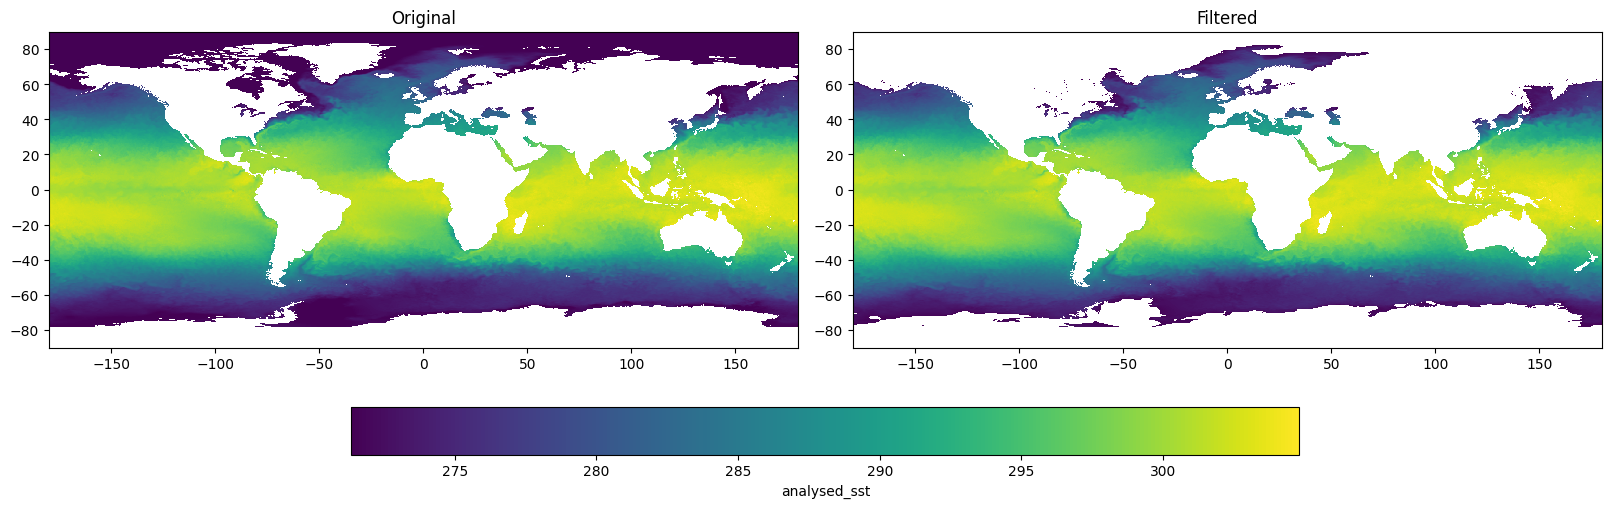

In [ ]:
from pathlib import Path

test = "TEMPO"
if test == "TEMPO":
    file_pattern = "TEMPO*"
    group = "product"
    #var_name = "vertical_column_stratosphere"
    var_name = "column_amount_o3"
elif test == "MUR":
    file_pattern = "*-JPL-L4*fv04.1*"
    group = "/"
    var_name = "analysed_sst"
elif test == "MUR25":
    file_pattern = "*-JPL-L4*fv04.2*"
    group = "/"
    var_name = "analysed_sst"
else:
    file_pattern = "*"
    group = "/"
    var_name = "test"

# 1️⃣ find files
in_dir = Path(settings["data_dir"])
out_dir = Path(settings["output_dir"])
filtered = next(out_dir.glob(f"{file_pattern}_filtered.nc"))
original = in_dir / filtered.name.replace("_filtered.nc", ".nc")

print("Original:", original)
print("Filtered:", filtered)

# 2️⃣ open them
ds_orig = xr.open_dataset(original, group=group)
ds_filt = xr.open_dataset(filtered, group=group)

print(ds_orig)
da_orig = ds_orig[var_name]
da_filt = ds_filt[var_name]

# 3️⃣ helper to get a pure 2D slice
def to_2d(da):
    # if there's a time dimension, grab the first timestep
    if "time" in da.dims:
        da2 = da.isel(time=0)
    else:
        da2 = da.squeeze()
    if da2.ndim != 2:
        raise ValueError(f"Cannot make 2D from dims {da2.dims}")
    return da2


da_o2 = to_2d(da_orig)
da_f2 = to_2d(da_filt)

# 4️⃣ plot side by side with common color scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# first get color limits from the original
vmin, vmax = float(da_o2.min()), float(da_o2.max())

im1 = da_o2.plot.pcolormesh(ax=ax1, add_colorbar=False, vmin=vmin, vmax=vmax)
ax1.set_title("Original")
ax1.set_xlabel("")
ax1.set_ylabel("")

im2 = da_f2.plot.pcolormesh(ax=ax2, add_colorbar=False, vmin=vmin, vmax=vmax)
ax2.set_title("Filtered")
ax2.set_xlabel("")
ax2.set_ylabel("")

# 5️⃣ shared colorbar
cbar = fig.colorbar(im2, ax=(ax1, ax2), orientation="horizontal", pad=0.1)
cbar.set_label(var_name)

plt.show()